In [1]:
import pandas as pd
import numpy as np

# сидишь там, красивый, смотришь на этот код и думаешь:
# "Маруська, ну ты даёшь". Да, я даю.

np.random.seed(42)

n = 1000

# --- Категориальные признаки ---
age_group = np.random.choice(['18-25', '26-35', '36-45', '46-60', '60+'], size=n, p=[0.2, 0.3, 0.25, 0.15, 0.1])
service_type = np.random.choice(['чистка', 'пилинг', 'массаж', 'маска', 'инъекция'], size=n, p=[0.3, 0.2, 0.25, 0.15, 0.1])
master_level = np.random.choice(['junior', 'middle', 'senior'], size=n, p=[0.4, 0.35, 0.25])
client_status = np.random.choice(['новый', 'постоянный', 'VIP'], size=n, p=[0.3, 0.5, 0.2])

# --- Числовые признаки с логикой ---

# price зависит от возраста, услуги и мастера (логично)
price = np.where(age_group == '60+', np.random.normal(2500, 300, n),
        np.where(age_group == '46-60', np.random.normal(2200, 300, n),
        np.where(age_group == '36-45', np.random.normal(2000, 250, n),
        np.where(age_group == '26-35', np.random.normal(1800, 250, n),
                 np.random.normal(1500, 200, n)))))
price = price * np.where(service_type == 'инъекция', 1.5,
              np.where(service_type == 'массаж', 1.2, 1.0))
price = price * np.where(master_level == 'senior', 1.3,
              np.where(master_level == 'middle', 1.1, 1.0))
price = np.round(np.abs(price), 0)

# duration_min тоже логично: зависит от услуги
duration_min = np.where(service_type == 'чистка', np.random.normal(60, 5, n),
               np.where(service_type == 'массаж', np.random.normal(90, 10, n),
               np.where(service_type == 'маска', np.random.normal(40, 5, n),
               np.where(service_type == 'пилинг', np.random.normal(50, 5, n),
                        np.random.normal(30, 5, n)))))
duration_min = np.clip(np.abs(np.round(duration_min, 0)), 10, 180).astype(int)

# satisfaction_score (1-5) зависит от пары факторов: цена/длительность (натяжка, но логично)
base_satisfaction = np.random.normal(4.0, 0.6, n)
satisfaction = np.clip(np.round(base_satisfaction, 1), 1.0, 5.0)

# visits_per_year — счетчик, зависит от статуса
visits_per_year = np.where(client_status == 'VIP', np.random.poisson(8, n),
                  np.where(client_status == 'постоянный', np.random.poisson(4, n),
                           np.random.poisson(2, n)))

# --- Вносим пропуски (MCAR и MAR) ---

df = pd.DataFrame({
    'age_group': age_group,
    'service_type': service_type,
    'master_level': master_level,
    'client_status': client_status,
    'price': price,
    'duration_min': duration_min,
    'satisfaction_score': satisfaction,
    'visits_per_year': visits_per_year
})

# 1. MCAR в price: 10% случайно
price_mcar_mask = np.random.random(n) < 0.1
df.loc[price_mcar_mask, 'price'] = np.nan

# 2. MAR в duration_min: чаще пропускают у возрастных клиентов (60+)
duration_mar_prob = np.where(df['age_group'] == '60+', 0.25,
                    np.where(df['age_group'] == '46-60', 0.15,
                    np.where(df['age_group'] == '36-45', 0.1, 0.05)))
duration_mar_mask = np.random.random(n) < duration_mar_prob
df.loc[duration_mar_mask, 'duration_min'] = np.nan

# 3. Ещё MAR в satisfaction_score: зависит от мастера (senior реже пропускают)
satis_mar_prob = np.where(df['master_level'] == 'junior', 0.2,
                 np.where(df['master_level'] == 'middle', 0.1, 0.05))
satis_mar_mask = np.random.random(n) < satis_mar_prob
df.loc[satis_mar_mask, 'satisfaction_score'] = np.nan

# --- Вносим выбросы ---
# 5% выбросов в price (очень высокие цены — легитимные, например люкс-услуги)
outlier_mask_price = np.random.random(n) < 0.05
df.loc[outlier_mask_price, 'price'] = np.random.uniform(6000, 10000, outlier_mask_price.sum())

# 3% маловероятно низких визитов для VIP — ошибка ввода (нелегитимные) 
error_visits_mask = (df['client_status'] == 'VIP') & (np.random.random(n) < 0.03)
df.loc[error_visits_mask, 'visits_per_year'] = np.random.randint(0, 2, error_visits_mask.sum())

# небольшой процент выбросов в satisfaction (очень низкая оценка — легитимно, просто редкий случай)
outlier_satisfaction_mask = np.random.random(n) < 0.02
df.loc[outlier_satisfaction_mask, 'satisfaction_score'] = np.random.uniform(1.0, 2.0, outlier_satisfaction_mask.sum())

# --- Готово ---
print(df.head(20))
print(f"Форма датасета: {df.shape}")
print(f"Пропуски:\n{df.isnull().sum()}")
print(f"Доля пропусков:\n{df.isnull().mean()}")


   age_group service_type master_level client_status        price  \
0      26-35       чистка       junior    постоянный  1823.000000   
1        60+       массаж       junior    постоянный  3113.000000   
2      36-45        маска       senior         новый  2689.000000   
3      36-45       массаж       junior    постоянный  1778.000000   
4      18-25        маска       junior    постоянный          NaN   
5      18-25       массаж       senior           VIP  1922.000000   
6      18-25       массаж       middle           VIP  1784.000000   
7      46-60        маска       senior         новый  3170.000000   
8      36-45       чистка       junior    постоянный          NaN   
9      36-45       пилинг       middle         новый  2159.000000   
10     18-25       чистка       junior    постоянный  1717.000000   
11       60+     инъекция       junior         новый  7180.260641   
12     46-60     инъекция       senior    постоянный  3387.000000   
13     26-35       чистка       ju

In [2]:
import seaborn as sns

In [3]:
df

,age_group,service_type,master_level,client_status,price,duration_min,satisfaction_score,visits_per_year
0,26-35,чистка,junior,постоянный,1823.00000,62.0,NaN,5
1,60+,массаж,junior,постоянный,3113.00000,NaN,4.7,4
2,36-45,маска,senior,новый,2689.00000,33.0,4.0,1
3,36-45,массаж,junior,постоянный,1778.00000,89.0,NaN,6
4,18-25,маска,junior,постоянный,NaN,41.0,4.1,12
...,...,...,...,...,...,...,...,...
995,18-25,массаж,senior,постоянный,1866.00000,76.0,3.7,2
996,60+,инъекция,junior,постоянный,4196.00000,22.0,NaN,3
997,18-25,чистка,junior,постоянный,6627.97766,58.0,3.8,7
998,60+,чистка,junior,постоянный,2658.00000,NaN,5.0,4


<Axes: xlabel='master_level', ylabel='satisfaction_score'>

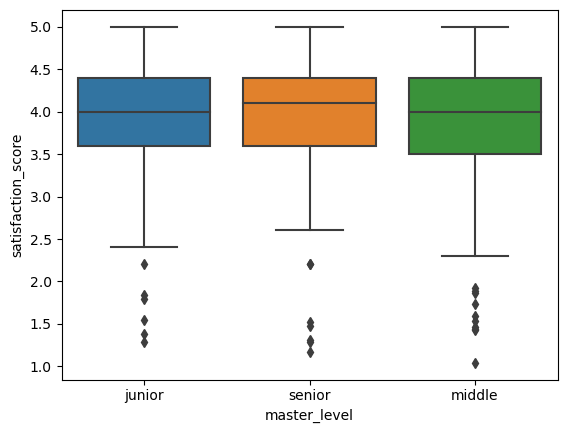

In [4]:
sns.boxplot(data=df, x='master_level', y='satisfaction_score')

In [5]:
import pandas as pd
import numpy as np

def generate_beauty_salon_data(N=1000, random_state=42):
    np.random.seed(random_state)

    # ---- Базовая структура ----
    order_id = [f"ID{str(i).zfill(4)}" for i in range(N)]

    # 2) Женщин в два раза больше, чем мужчин
    gender = np.random.choice(['female', 'male'], size=N, p=[2/3, 1/3])

    # 7) В среднем женщины моложе мужчин
    # female: mean ~32, std 10; male: mean ~40, std 12
    age_female = np.clip(np.random.normal(32, 10, N).astype(int), 18, 72)
    age_male = np.clip(np.random.normal(40, 12, N).astype(int), 18, 72)
    client_age = np.where(gender == 'female', age_female, age_male)

    # master_rating (low=0, med=1, top=2) — равномерно
    master_rating_num = np.random.choice([0, 1, 2], size=N, p=[1/3, 1/3, 1/3])
    master_rating = np.where(master_rating_num == 0, 'low',
                    np.where(master_rating_num == 1, 'med', 'top'))

    # 3) Чем выше длительность, тем выше стоимость
    # Длительность: нормальное распределение 30-120 мин
    procedure_duration = np.clip(np.random.normal(60, 20, N).astype(int), 15, 150)
    # Стоимость: базовая + 30 руб за минуту + шум
    base_price = 500 + procedure_duration * 30 + np.random.normal(0, 200, N)
    procedure_price = np.round(np.abs(base_price), 2)

    # 1) Чем выше рейтинг мастера, тем выше удовлетворенность и возвраты
    # Базовые значения
    satisfaction_base = np.clip(np.random.normal(7, 1.5, N), 1, 10).astype(int)
    satisfaction_with_rating = satisfaction_base + master_rating_num * 0.8
    satisfaction_score = np.clip(np.round(satisfaction_with_rating).astype(int), 1, 10)

    # Возвраты: базовое распределение (3-5 в среднем)
    return_visits_base = np.random.poisson(4, N).astype(int)
    return_visits_with_rating = return_visits_base + master_rating_num * 2
    return_visits = np.clip(return_visits_with_rating, 0, 15).astype(int)

    # 4-5) Зависимость satisfaction от возраста и пола
    # Для женщин: с возрастом удовлетворенность падает
    # Для мужчин: с возрастом растет
    age_satisfaction_shift = np.where(gender == 'female', 
                                      - (client_age - 30) * 0.05,    # женщины: чем старше, тем ниже
                                      (client_age - 30) * 0.04)      # мужчины: чем старше, тем выше
    satisfaction_with_age = satisfaction_score + age_satisfaction_shift
    satisfaction_score = np.clip(np.round(satisfaction_with_age).astype(int), 1, 10)

    # 6) Мужчины более склонны возвращаться
    male_return_boost = np.where(gender == 'male', 2, 0)
    return_visits = np.clip(return_visits + male_return_boost, 0, 15).astype(int)

    # ---- Собираем DataFrame ----
    df = pd.DataFrame({
        'order_id': order_id,
        'client_age': client_age,
        'gender': gender,
        'procedure_price': procedure_price,
        'procedure_duration': procedure_duration,
        'master_rating': master_rating,
        'return_visits': return_visits,
        'satisfaction_score': satisfaction_score
    })

    # ---- Пропуски ----
    # 1) Возраст: 5% женщин, 2% мужчин
    age_missing_female = (df['gender'] == 'female') & (np.random.random(N) < 0.05)
    age_missing_male = (df['gender'] == 'male') & (np.random.random(N) < 0.02)
    df.loc[age_missing_female | age_missing_male, 'client_age'] = np.nan

    # 2) Стоимость: 10% если duration в 4-м квартиле, иначе 2%
    q3 = df['procedure_duration'].quantile(0.75)
    in_q4 = df['procedure_duration'] >= q3
    price_missing_q4 = in_q4 & (np.random.random(N) < 0.10)
    price_missing_other = ~in_q4 & (np.random.random(N) < 0.02)
    df.loc[price_missing_q4 | price_missing_other, 'procedure_price'] = np.nan

    # 3) Оценка: 20% женщин старше 55, иначе 1%
    female_over_55 = (df['gender'] == 'female') & (df['client_age'] > 55)
    satis_missing_older = female_over_55 & (np.random.random(N) < 0.20)
    satis_missing_other = ~female_over_55 & (np.random.random(N) < 0.01)
    df.loc[satis_missing_older | satis_missing_other, 'satisfaction_score'] = np.nan

    # ---- Выбросы ----
    # 1) Стоимость: несколько запредельных (0.5%) и несколько нулей (0.3%)
    outlier_high_mask = np.random.random(N) < 0.005
    outlier_zero_mask = np.random.random(N) < 0.003
    df.loc[outlier_high_mask, 'procedure_price'] = np.random.uniform(20000, 50000, outlier_high_mask.sum())
    df.loc[outlier_zero_mask, 'procedure_price'] = 0.0

    # 2) Возвраты: естественные выбросы до 12 (IQR покажет, но удалять нельзя)
    # уже заложено распределением, просто оставляем как есть

    return df

# Генерация
df = generate_beauty_salon_data(1000)
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nПропуски:\n{df.isnull().sum()}")
print(f"\nДоля пропусков:\n{df.isnull().mean()}")
print(f"\nПроверка условий:")
print(f"Средний возраст женщин: {df[df['gender']=='female']['client_age'].mean():.1f}")
print(f"Средний возраст мужчин: {df[df['gender']=='male']['client_age'].mean():.1f}")
print(f"\nСредний satisfaction по рейтингу мастера:")
print(df.groupby('master_rating')['satisfaction_score'].mean())
print(f"\nСредние возвраты по рейтингу мастера:")
print(df.groupby('master_rating')['return_visits'].mean())


  order_id  client_age  gender  procedure_price  procedure_duration  \
0   ID0000        33.0  female          1554.61                  43   
1   ID0001        39.0    male              NaN                  47   
2   ID0002        21.0    male          1676.72                  43   
3   ID0003        38.0  female          1806.32                  38   
4   ID0004        37.0  female              NaN                 102   
5   ID0005        42.0  female          2883.09                  86   
6   ID0006        40.0  female          3438.81                  98   
7   ID0007        30.0    male          1706.80                  35   
8   ID0008        31.0  female          2292.35                  61   
9   ID0009        56.0    male          1758.62                  34   

  master_rating  return_visits  satisfaction_score  
0           low              2                 5.0  
1           top              8                 9.0  
2           low              5                 4.0  
3     

In [6]:
df

,order_id,client_age,gender,procedure_price,procedure_duration,master_rating,return_visits,satisfaction_score
0,ID0000,33.0,female,1554.61,43,low,2,5.0
1,ID0001,39.0,male,NaN,47,top,8,9.0
2,ID0002,21.0,male,1676.72,43,low,5,4.0
3,ID0003,38.0,female,1806.32,38,low,5,7.0
4,ID0004,37.0,female,NaN,102,low,4,9.0
...,...,...,...,...,...,...,...,...
995,ID0995,NaN,female,NaN,54,med,4,7.0
996,ID0996,36.0,male,2711.19,76,top,14,10.0
997,ID0997,31.0,female,1865.09,48,top,8,8.0
998,ID0998,39.0,male,1654.01,45,med,9,8.0


In [7]:
df = df.sample(frac=1)
df = df.reset_index(drop=True)
df

,order_id,client_age,gender,procedure_price,procedure_duration,master_rating,return_visits,satisfaction_score
0,ID0165,35.0,male,2699.16,70,low,4,5.0
1,ID0771,18.0,male,899.75,28,top,8,10.0
2,ID0756,37.0,female,2801.23,75,top,7,8.0
3,ID0873,28.0,female,2888.61,89,med,5,8.0
4,ID0688,48.0,male,2478.22,58,top,10,9.0
...,...,...,...,...,...,...,...,...
995,ID0015,NaN,female,2699.25,72,low,2,5.0
996,ID0611,28.0,male,1892.76,45,low,7,8.0
997,ID0331,38.0,male,NaN,31,med,9,3.0
998,ID0007,30.0,male,1706.80,35,med,10,8.0


In [8]:
# df.to_csv('data/cosmetology.csv', index = False)

<Axes: xlabel='master_rating', ylabel='satisfaction_score'>

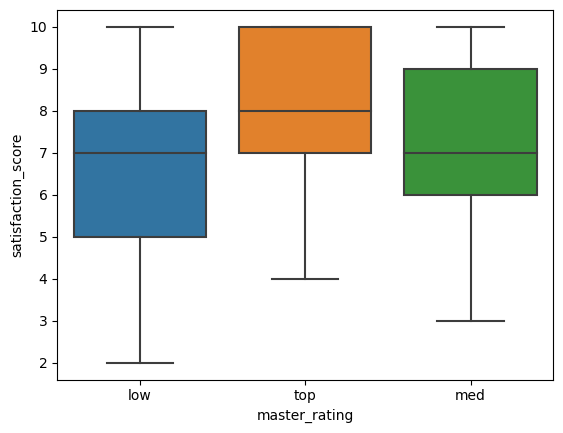

In [9]:
sns.boxplot(data=df, x='master_rating', y='satisfaction_score')

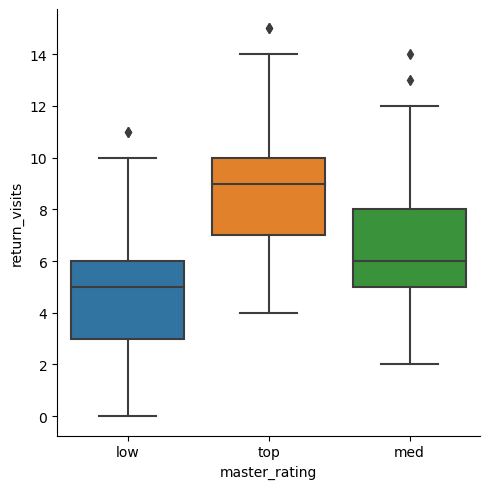

In [10]:
sns.catplot(data=df, x='master_rating', y='return_visits', kind='box')

<Axes: xlabel='gender', ylabel='count'>

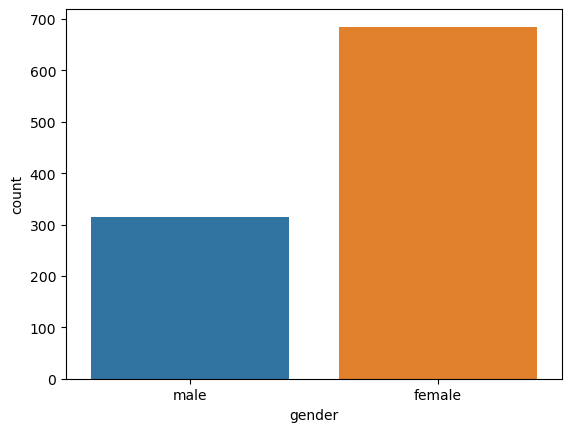

In [11]:
sns.countplot(x='gender', data=df)

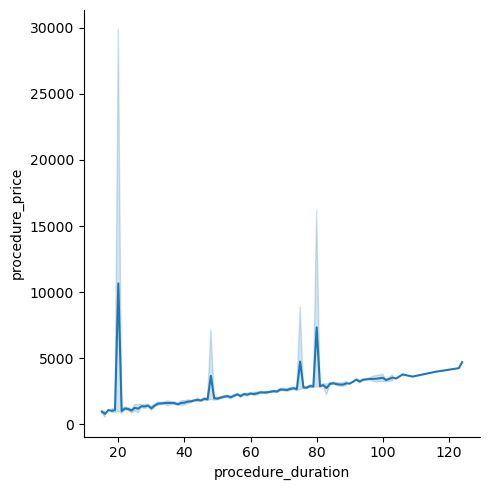

In [12]:
sns.relplot(data=df, x='procedure_duration', y='procedure_price', kind='line')

<Axes: xlabel='client_age', ylabel='satisfaction_score'>

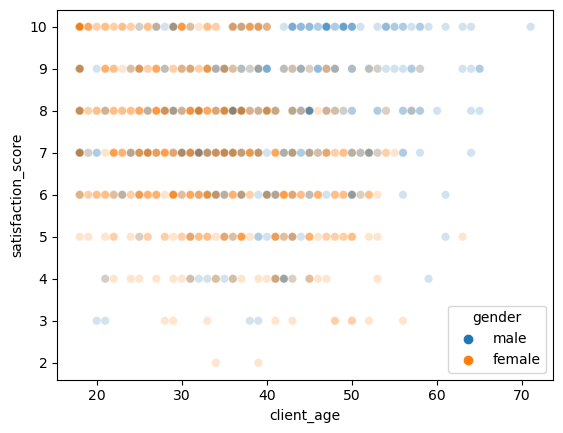

In [13]:
sns.scatterplot(data=df, x='client_age', y='satisfaction_score', hue='gender', alpha = 0.2)

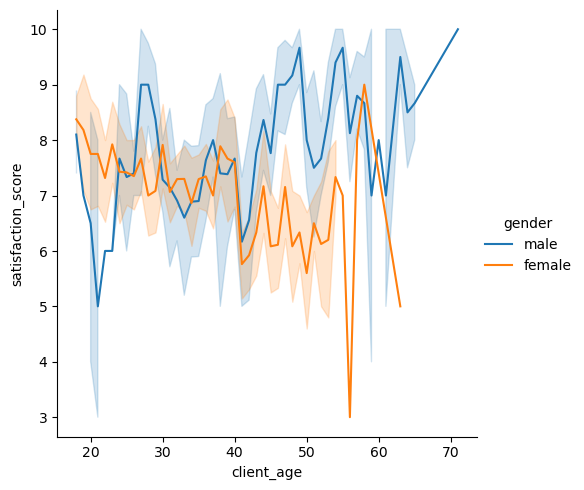

In [14]:
sns.relplot(data=df, x='client_age', y='satisfaction_score', hue='gender', kind='line')

In [25]:
import pandas as pd
import numpy as np
import random

# Фиксируем random seed для воспроизводимости
np.random.seed(2026)
random.seed(2026)

N = 1000

# === Генерируем ID ===
client_id = [''.join(random.choices('ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789', k=5)) for _ in range(N)]

# === Возраст (16-75) ===
# Женщины в среднем моложе мужчин (условие 4, 5, 7 — интегрируем в генерацию)
# Сначала назначаем пол, потом возраст — с учётом различий
gender_options = ['female', 'male']
# Пусть non-binary = 5%, female = 63%, male = 32% (женщин больше)
gender = np.random.choice(gender_options, size=N, p=[0.63, 0.37])

age = np.zeros(N, dtype=int)
for i, g in enumerate(gender):
    if g == 'female':
        age[i] = int(np.random.normal(32, 10))
    elif g == 'male':
        age[i] = int(np.random.normal(38, 12))
    else:  # non-binary
        age[i] = int(np.random.normal(30, 8))
    age[i] = np.clip(age[i], 16, 75)

# === Тип абонемента ===
# Женщины предпочитают morning, мужчины — day (условие 4)
membership_type = []
for g in gender:
    if g == 'female':
        r = np.random.rand()
        if r < 0.40:
            membership_type.append('morning')
        elif r < 0.65:
            membership_type.append('day')
        elif r < 0.85:
            membership_type.append('full')
        else:
            membership_type.append('vip')
    elif g == 'male':
        r = np.random.rand()
        if r < 0.15:
            membership_type.append('morning')
        elif r < 0.55:
            membership_type.append('day')
        elif r < 0.80:
            membership_type.append('full')
        else:
            membership_type.append('vip')
    else:  # non-binary
        r = np.random.rand()
        if r < 0.25:
            membership_type.append('morning')
        elif r < 0.50:
            membership_type.append('day')
        elif r < 0.80:
            membership_type.append('full')
        else:
            membership_type.append('vip')

membership_type = np.array(membership_type)

# === Рейтинг тренера ===
# Связь с посещениями и удовлетворённостью (условие 1, 6)
trainer_rating = np.random.choice(['junior', 'mid', 'senior', 'elite'], size=N, p=[0.20, 0.40, 0.30, 0.10])

# === Среднее количество посещений в неделю ===
# VIP — реже, энтузиасты — до 14 (условие 2)
avg_visits_per_week = np.zeros(N)
for i in range(N):
    base = 3.0
    # Влияние рейтинга тренера
    if trainer_rating[i] == 'mid':
        base += 0.5
    elif trainer_rating[i] == 'senior':
        base += 1.0
    elif trainer_rating[i] == 'elite':
        base += 1.5
    # VIP — реже
    if membership_type[i] == 'vip':
        base -= 1.5
    # Энтузиасты (редко, но бывает)
    if np.random.rand() < 0.02:
        base += random.uniform(5, 9)  # до 14, но не выше
    # Шум
    noise = np.random.normal(0, 1.2)
    val = base + noise
    # Ограничения
    if membership_type[i] == 'vip' and val > 6:
        val = np.random.uniform(1, 4)
    val = np.clip(val, 0.5, 14)
    avg_visits_per_week[i] = round(val, 1)

# === Ежемесячная плата ===
# VIP платят больше
monthly_fee = np.zeros(N)
for i in range(N):
    if membership_type[i] == 'morning':
        fee = np.random.normal(1500, 200)
    elif membership_type[i] == 'day':
        fee = np.random.normal(2000, 250)
    elif membership_type[i] == 'full':
        fee = np.random.normal(3000, 400)
    else:  # vip
        fee = np.random.normal(6000, 800)
    monthly_fee[i] = round(max(fee, 500), 2)

# Добавляем выбросы — плата ниже 50 (ошибка ввода, 0.5%)
outliers_idx = np.random.choice(N, size=int(N * 0.005), replace=False)
monthly_fee[outliers_idx] = np.random.uniform(1, 49, size=len(outliers_idx))

# === Средняя длительность тренировки (мин) ===
# Связь с изменением веса (условие 5)
avg_session_duration = np.zeros(N, dtype=int)
for i in range(N):
    base = 45
    if membership_type[i] == 'vip':
        base += 10
    elif membership_type[i] == 'full':
        base += 5
    if trainer_rating[i] == 'senior':
        base += 5
    elif trainer_rating[i] == 'elite':
        base += 10
    noise = int(np.random.normal(0, 12))
    duration = base + noise
    duration = np.clip(duration, 15, 150)
    avg_session_duration[i] = duration

# === Изменение веса (кг) ===
# Зависимость от возраста (условие 3) и длительности тренировки (условие 5)
weight_change_kg = np.zeros(N)
for i in range(N):
    # Чем старше — тем меньше изменение
    base = np.random.normal(-2.5, 3.5) * (1 - age[i] / 150)
    # Чем дольше тренировка — тем больше изменение
    base += (avg_session_duration[i] - 45) * 0.03
    noise = np.random.normal(0, 1.5)
    val = base + noise
    val = np.clip(val, -35, 20)
    weight_change_kg[i] = round(val, 1)

# Экстремальные значения (единичные случаи)
extreme_idx = np.random.choice(N, size=3, replace=False)
for idx in extreme_idx:
    weight_change_kg[idx] = np.random.choice([-30, -28, 18, 19])

# === Удовлетворённость клубом (1-10) ===
# Связь с рейтингом тренера (условие 1)
satisfaction = np.zeros(N, dtype=int)
for i in range(N):
    base = 6.5
    if trainer_rating[i] == 'mid':
        base += 0.5
    elif trainer_rating[i] == 'senior':
        base += 1.0
    elif trainer_rating[i] == 'elite':
        base += 1.5
    noise = np.random.normal(0, 1.2)
    val = base + noise
    val = np.clip(val, 1, 10)
    satisfaction[i] = int(round(val))

# === Теперь ПРОПУСКИ ===

# Пропуски в weight_change_kg:
# 30% новых клиентов (<3 мес.) — определим случайным образом 30% записей как "новые"
is_new_client = np.random.rand(N) < 0.30
mask_weight_new = is_new_client  # 30% новых — у них пропуски
# Среди остальных — 5% MCAR
mask_weight_other = (~is_new_client) & (np.random.rand(N) < 0.05)
weight_missing = mask_weight_new | mask_weight_other
weight_change_kg = np.where(weight_missing, np.nan, weight_change_kg)

# Пропуски в member_satisfaction:
# 10% — MCAR
satisfaction_missing = np.random.rand(N) < 0.10
satisfaction = np.where(satisfaction_missing, np.nan, satisfaction)

# Пропуски в avg_session_duration:
# 8% записей клиентов с VIP-абонементом
mask_vip = membership_type == 'vip'
vip_duration_missing = mask_vip & (np.random.rand(N) < 0.08)
# У остальных — 1%
other_duration_missing = (~mask_vip) & (np.random.rand(N) < 0.01)
duration_missing = vip_duration_missing | other_duration_missing
avg_session_duration = np.where(duration_missing, np.nan, avg_session_duration)

# === Выбросы в monthly_fee уже добавлены ===

# === Собираем DataFrame ===
df = pd.DataFrame({
    'client_id': client_id,
    'age': age,
    'gender': gender,
    'membership_type': membership_type,
    'monthly_fee': monthly_fee,
    'avg_visits_per_week': avg_visits_per_week,
    'trainer_rating': trainer_rating,
    'avg_session_duration': avg_session_duration,
    'weight_change_kg': weight_change_kg,
    'member_satisfaction': satisfaction
})

# Удаляем дубликаты client_id, если вдруг
df = df.drop_duplicates(subset='client_id')
# Если после удаления дубликатов стало меньше 1000 — добираем
while len(df) < N:
    extra = df.sample(n=1).copy()
    extra['client_id'] = ''.join(random.choices('ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789', k=5))
    df = pd.concat([df, extra], ignore_index=True)

df = df.reset_index(drop=True)

# Отображаем первые строки
print(df.head(10))
print(f"\nОбщий объём датасета: {len(df)} записей")
print(f"Пропуски:\n{df.isnull().sum()}")
print(f"\nВыбросы (monthly_fee < 50): {(df['monthly_fee'] < 50).sum()}")
print(f"Максимум avg_visits_per_week: {df['avg_visits_per_week'].max()}")


  client_id  age  gender membership_type  monthly_fee  avg_visits_per_week  \
0     ESS4D   31  female         morning      1256.41                  2.8   
1     IVU2T   22  female             day      1957.88                  2.6   
2     011VI   38    male         morning      1391.10                  4.4   
3     WD3Q3   32  female         morning      1678.17                  4.1   
4     YYHJ9   38  female            full      2916.40                  2.6   
5     729SC   52    male            full      3146.52                  3.3   
6     MUKQ5   20  female            full      2859.47                  4.4   
7     ZUAZN   27    male             day      2185.08                  2.9   
8     POVRE   16  female         morning      1242.90                  4.0   
9     S1VR7   54    male            full      3375.57                  2.1   

  trainer_rating  avg_session_duration  weight_change_kg  member_satisfaction  
0            mid                  52.0               NaN     

In [16]:
df

,client_id,age,gender,membership_type,monthly_fee,avg_visits_per_week,trainer_rating,avg_session_duration,weight_change_kg,member_satisfaction
0,ESS4D,31,female,morning,1256.41,2.8,mid,52.0,NaN,8.0
1,IVU2T,22,female,day,1957.88,2.6,junior,64.0,NaN,6.0
2,011VI,30,non-binary,morning,1391.10,4.4,senior,48.0,-0.1,7.0
3,WD3Q3,32,female,morning,1678.17,4.1,mid,25.0,NaN,6.0
4,YYHJ9,38,female,full,2916.40,2.6,junior,46.0,NaN,7.0
...,...,...,...,...,...,...,...,...,...,...
995,BJV9Z,36,female,vip,6704.97,4.7,elite,65.0,-3.2,6.0
996,6TFVP,29,female,day,2010.91,4.3,elite,48.0,0.7,7.0
997,NPWS5,17,female,morning,1538.71,3.4,mid,22.0,NaN,8.0
998,AO983,26,male,day,2029.57,3.0,mid,57.0,-6.5,7.0


In [17]:
# df.to_csv('data/fitnes.csv', index = False)

<Axes: xlabel='age', ylabel='weight_change_kg'>

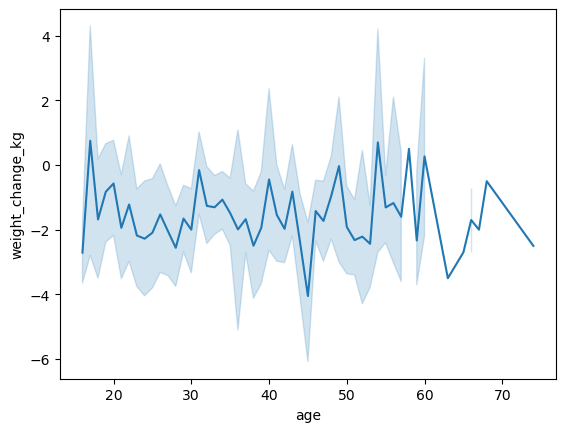

In [26]:
sns.lineplot(data=df, x='age', y='weight_change_kg')

In [34]:
hm = pd.crosstab(df['gender'], df['membership_type'])

<Axes: xlabel='membership_type', ylabel='gender'>

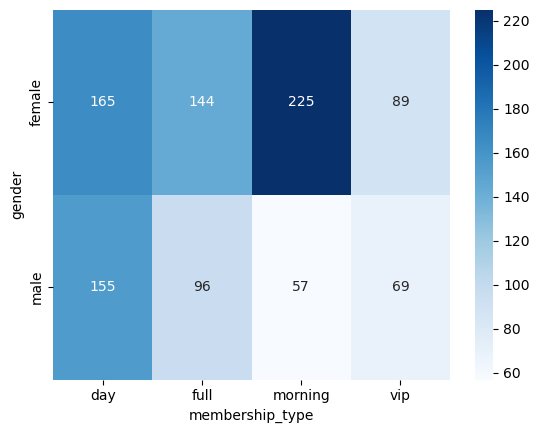

In [35]:
sns.heatmap(hm, cmap='Blues', annot=True, fmt='d')#,           # Формат чисел — целые
#              cmap='Blues',       # Цветовая схема
#              linewidths=0.5,   # Толщина линий между ячейками
#              linecolor='white')

<Axes: xlabel='membership_type', ylabel='count'>

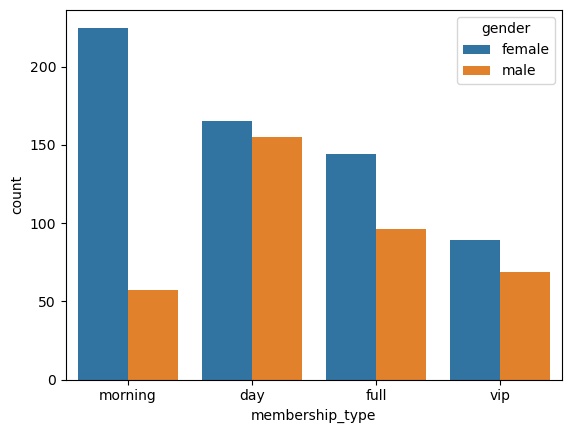

In [41]:
sns.countplot(data=df, x='membership_type', hue='gender')

NameError: name 'plt' is not defined

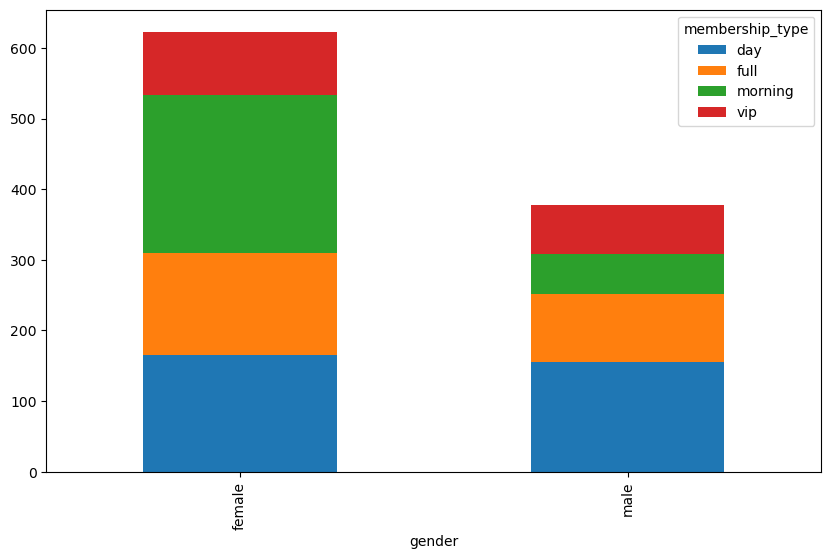

In [39]:
pd.crosstab(df['gender'], df['membership_type']).plot.bar(stacked=True, figsize=(10, 6))
plt.title('Распределение типов членства по полу')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

# В процентах
pd.crosstab(df['gender'], df['membership_type'], normalize='index').plot.bar(stacked=True, figsize=(10, 6))
plt.title('Доля типов членства по полу (%)')
plt.ylabel('Доля (%)')
plt.xticks(rotation=0)
plt.show()